In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import glob
from google.colab import files
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


# 음성데이터 세션 나누기

In [2]:
AI_root = glob.glob(r"/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/*")
ori_root = glob.glob(r"/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/원본/*")
X_path = AI_root + ori_root
print(X_path)

['/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.vampire - ROSÉ (ai cover).wav', "/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Taylor Swift IA - we can't be friends (wait for your love) (artificial intelligence version).wav", '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Passenger - LET HER GO (ED SHEERAN - A.I COVER LYRICS).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Jungkook - Off My Face (AI Cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Copy of Standing Next to You - AI theWeeknd.wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Copy of Jungkook - Die For You (AI cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.CHIQUITA Ai Cover “ 2002” (Anne Marie).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Avril Lavigne - August (Taylor Swift Cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/AI/AI.Avril Lavigne - 3am (Halsey AI Cover).wav', '/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/원본/ori.Taylor Swift – august.wav', '/gdrive/MyDrive/빅데이터 45기_파이널 

In [3]:
pip install pydub

In [4]:
#음원 구간별 추출

from pydub import AudioSegment
import os

for a in X_path:
  # wav 파일 로드
  audio = AudioSegment.from_wav(a)

  # 분할 간격 설정 (밀리초 단위)
  interval = 10 * 1000  # 10초 = 10,000 밀리초
  step = 5 * 1000  # 5초 = 5,000 밀리초

  # 전체 길이
  length = len(audio) #밀리초로 환산됨


  # 저장할 디렉토리 설정
  output_dir = r'/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save'

  # 분할 및 저장
  for i in range(0, length, step):
      start_time = i  # 시작 시간 (밀리초 단위)
      end_time = i + interval  # 종료 시간 (밀리초 단위)
      split_audio = audio[start_time:end_time]
      start_sec = start_time // 1000  # 시작 시간 (초 단위)
      end_sec = end_time // 1000  # 종료 시간 (초 단위)
      filename = os.path.join(output_dir, f"output_{start_sec}-{end_sec}_{os.path.basename(a)}.wav")
      split_audio.export(filename, format="wav")
      print(f"Saved {filename}")

  print("분할 완료")


Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_0-10_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_5-15_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_10-20_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_15-25_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_20-30_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_25-35_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_30-40_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_35-45_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_40-50_AI.vampire - ROSÉ (ai cover).wav.wav
Saved /gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/output_45-55_AI.vampire - ROSÉ (

# 모델링 시작

In [5]:
#구간별 추출한 데이터 경로 저장
X_path_new = glob.glob(r"/gdrive/MyDrive/빅데이터 45기_파이널 프로젝트/음원데이터/save/*")
print(len(X_path_new))

800


In [6]:
import ntpath # 특정 경로에서 파일들을 가져오는 라이브러리
y = np.empty((0, 1)) # 비어있는 리스트 만들기

for f in X_path_new:
    if 'ori' in ntpath.basename(f): #  음성 데이터가 있는 디렉토리의 데이터가 '원본' 음성 : 0
        resp = np.array([0])  #   [0]
    elif 'AI' in ntpath.basename(f): # 음성 데이터가 있는 디렉토리의 데이터가 'AI' 음성 : 1
        resp = np.array([1])  # [1]
    resp = resp.reshape(1, 1)
    y = np.vstack((y, resp))
print (y)

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.

In [7]:
# 데이터셋 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_path_new, y, test_size=0.25, random_state=42)
print(len(X_train)) # 600
print(len(X_test)) # 200

600
200


In [8]:
# 첫 번째 파일의 샘플 레이트 확인
sample_rate = librosa.load(X_train[0],sr = 16000)[1]
print(sample_rate)

16000


In [9]:
# 음성파일 읽기 & 디지털 변환 함수
def librosa_read_wav_files(wav_files):
    if not isinstance(wav_files, list): # isinstance(1, int) # 1이 int형인지 알아본다. 결과는 True
        wav_files = [wav_files]
    return [librosa.load(f, sr = 16000)[0] for f in wav_files] # 음성파일 읽기

In [10]:
# train/test 음성파일 읽기
X_train2 = librosa_read_wav_files(X_train)
X_test2  = librosa_read_wav_files(X_test)
print(len(X_train2)) # 600
print(len(X_test2)) # 200


600
200


In [11]:
# 오디오 특징 추출 함수
def extract_features(audio_samples, sample_rate):
    extracted_features = np.empty((0, 101)) # (1,101) : 101개의 값을 받을 메모리를 할당하겠다는 뜻
    if not isinstance(audio_samples, list):
        audio_samples = [audio_samples]

    for sample in audio_samples:
        zero_cross_feat = librosa.feature.zero_crossing_rate(sample).mean()
        mfccs = librosa.feature.mfcc(y=sample, sr=sample_rate, n_mfcc=100) # 오디오에서 40개 특징 추출
        mfccsscaled = np.mean(mfccs.T,axis=0)  # 각 주파수별 평균값을 구하기
        mfccsscaled = np.append(mfccsscaled, zero_cross_feat)
        mfccsscaled = mfccsscaled.reshape(1, 101)
        extracted_features = np.vstack((extracted_features, mfccsscaled))
    return extracted_features

In [12]:
# 오디오 특징 추출
# wave_rate 에 개과 고양이에 속하는 주파수 영역을 주어야 한다.

X_train_features = extract_features(X_train2, sample_rate) # wav_rate=22050(sample_rate)
X_test_features  = extract_features(X_test2, sample_rate) # wav_rate=22050(sample_rate)
print(X_train_features.shape) # (600, 101)
print(X_test_features.shape) # (200, 101)

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=272
  warnings.warn(


(600, 101)
(200, 101)


In [13]:
from keras import layers
from keras import models
from keras import optimizers
from keras import losses
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [14]:
# 신경망 구축
model = models.Sequential()
model.add(layers.Dense(100, activation = 'relu', input_shape = (101, ))) # 입력층 : 41개 오디오 특징
model.add(layers.Dense(50, activation = 'relu'))
model.add(layers.Dense(1, activation = 'sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               10200     
                                                                 
 dense_1 (Dense)             (None, 50)                5050      
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 15301 (59.77 KB)
Trainable params: 15301 (59.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
# 학습환경
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [16]:
history = model.fit(X_train_features, y_train, epochs=50, batch_size=32, validation_data=(X_test_features,y_test))


Epoch 1/50
19/19 [==============================] - 3s 19ms/step - loss: 1.6730 - accuracy: 0.5467 - val_loss: 0.8311 - val_accuracy: 0.6700
Epoch 2/50
19/19 [==============================] - 0s 6ms/step - loss: 0.6781 - accuracy: 0.6733 - val_loss: 0.5914 - val_accuracy: 0.6900
Epoch 3/50
19/19 [==============================] - 0s 5ms/step - loss: 0.5307 - accuracy: 0.7450 - val_loss: 0.4949 - val_accuracy: 0.7850
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.5629 - accuracy: 0.7767 - val_loss: 0.4534 - val_accuracy: 0.7700
Epoch 5/50
19/19 [==============================] - 0s 5ms/step - loss: 0.4538 - accuracy: 0.7700 - val_loss: 0.4899 - val_accuracy: 0.8100
Epoch 6/50
19/19 [==============================] - 0s 6ms/step - loss: 0.4098 - accuracy: 0.8467 - val_loss: 0.4676 - val_accuracy: 0.7650
Epoch 7/50
19/19 [==============================] - 0s 6ms/step - loss: 0.3304 - accuracy: 0.8850 - val_loss: 0.4399 - val_accuracy: 0.7800
Epoch 8/50
19/19 [=

Text(0, 0.5, 'ACC')

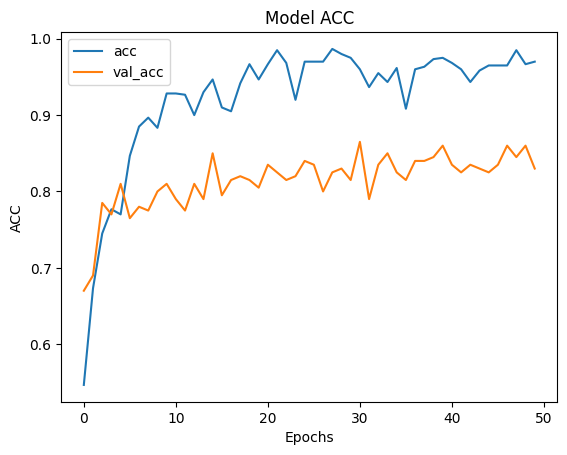

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['acc','val_acc'])
plt.title('Model ACC')
plt.xlabel('Epochs')
plt.ylabel('ACC')